## Hälsostudie
**Student:** Wendy Mermet

**Datakälla:** "health_study_dataset.csv.csv"


**Sammanfattning av medelvärde, median, min och max för:**
- ålder
- vikt
- längd
- systoliskt blodtryck
- kolesterol



In [1]:
import src.HealthAnalyzeTools as hat

analysis = hat.HealthAnalyzer()
analysis.main_summary()


In column "age":
The average is 49.43
The median is 50.00
The minimum is 18.00
The maximum is 90.00

In column "height":
The average is 171.85
The median is 171.35
The minimum is 144.40
The maximum is 200.40

In column "weight":
The average is 73.41
The median is 73.20
The minimum is 33.70
The maximum is 114.40

In column "systolic_bp":
The average is 149.18
The median is 149.40
The minimum is 106.80
The maximum is 185.90

In column "cholesterol":
The average is 4.93
The median is 4.97
The minimum is 2.50
The maximum is 7.88



**Dashboard som visar följande grafer från hälsostudiedata**
- Histogram över blodtryck
- Boxplot över vikt per kön
- Stapeldiagram över andelen rökare


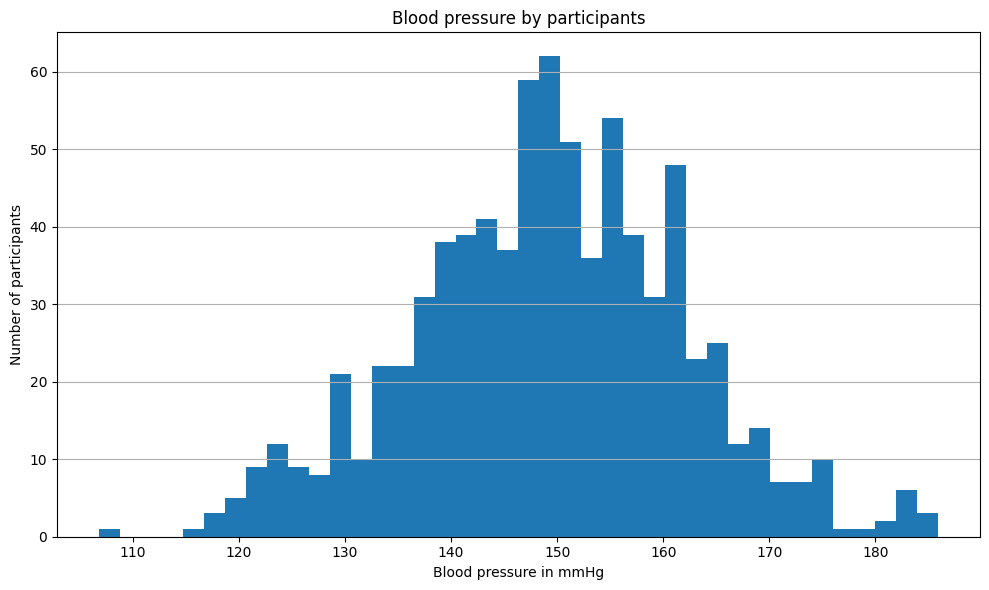

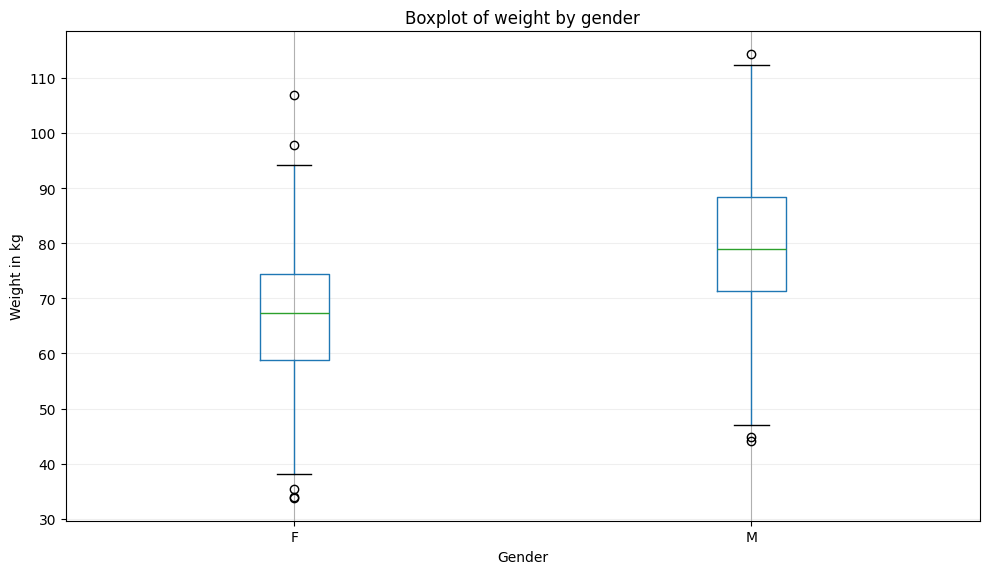

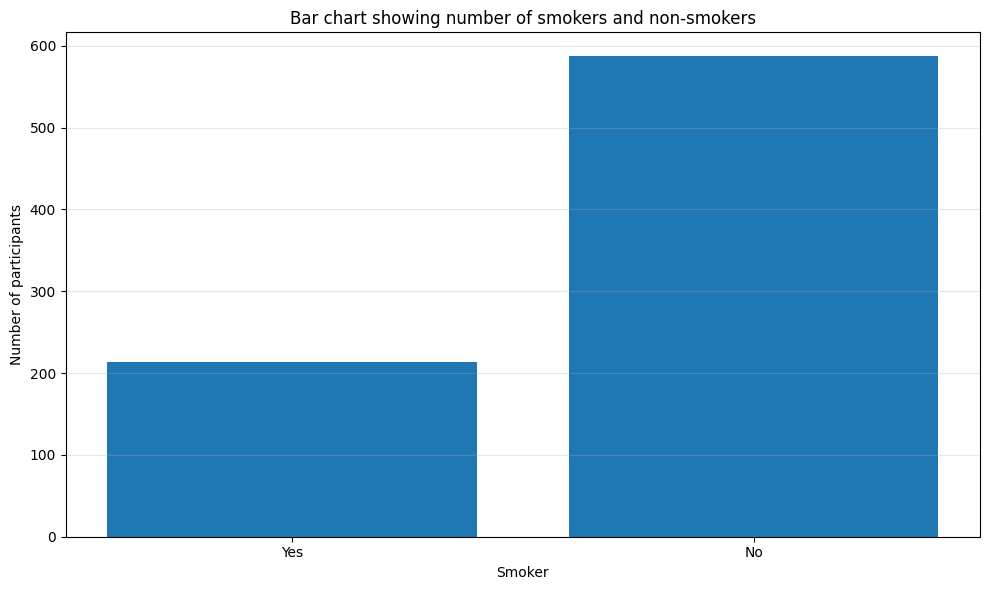

In [2]:
g1 = analysis.plot_blood_pressure_histogram() # histogram över blodtryck

g2 = analysis.plot_weight_boxplot() # boxplot över vikt per kön

g3 = analysis.plot_smoker_bar_chart() #stapeldiagram över andelen rökare

In [3]:
#import src.visuals as vis
#from src.io_utils import df

#vis.dashboard(g1, g2, g3)


Vi gör en enkel simulering för att förstå hur vanligt det är att deltagare i datasetet är sjuka.

1. **Räkna ut verklig andel:**  
   Först tar vi reda på hur stor del av personerna i det verkliga materialet som är sjuka.

2. **Skapa en simulerad grupp:**  
   När vi vet den verkliga andelen skapar vi sedan 1 000 påhittade personer.  
   Var och en av dessa får samma chans att vara sjuk som den verkliga andelen vi räknade fram.

3. **Jämför verklighet och simulering:**  
   När simuleringen är klar jämför vi hur många av de 1 000 påhittade personerna som är sjuka med hur många som faktiskt var sjuka i verkligheten.

Detta hjälper oss att se hur väl simuleringen stämmer överens med det riktiga datamaterialet.

In [4]:
stats = hat.HealthStatistics()

print(f"~{stats.perc_sick_participants():.3f}% of the participants declare having a disease")

~0.059% of the participants declare having a disease


In [5]:
mean_diseases, mean_sick_df = stats.simulate_disease()

print(f"The average of sick participants in the simulated data base of 1 000 is {mean_diseases:.3f}%\nThe average of sick participants in the original data base is {mean_sick_df:.3f}%")


The average of sick participants in the simulated data base of 1 000 is 0.056%
The average of sick participants in the original data base is 0.059%


Det faktum att simuleringen och det verkliga utfallet ligger så nära varandra visar att era riktiga data följer det sannolikhetsmönster som vi använde i simuleringen. Det betyder att simuleringen stämmer bra överens med det riktiga datamaterialet, vilket var målet i detta steg.

Nu beräknar vi ett **konfidensintervall för medelvärdet av systolic_bp** med hjälp av två olika metoder:
- med normalapproximation
- med bootstrap method


Using the normal approximation method:
the 95% confidence intervall for the average of the blood pressure is 148.298 -149.030 mmHg. 


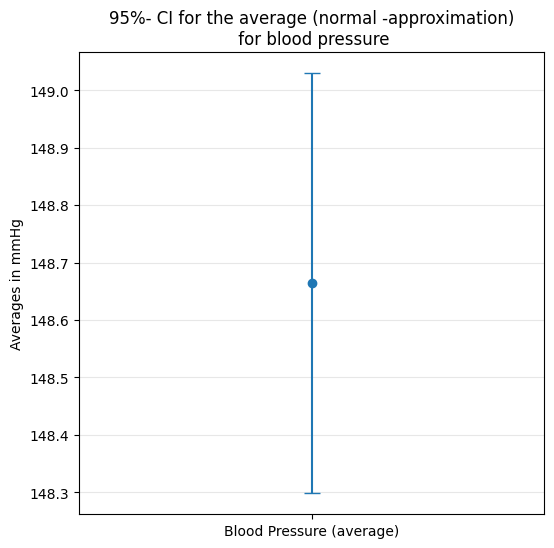

Using the normal approximation method:
the 95% confidence intervall for the average of the blood pressure is 148.290 -149.032 mmHg. 


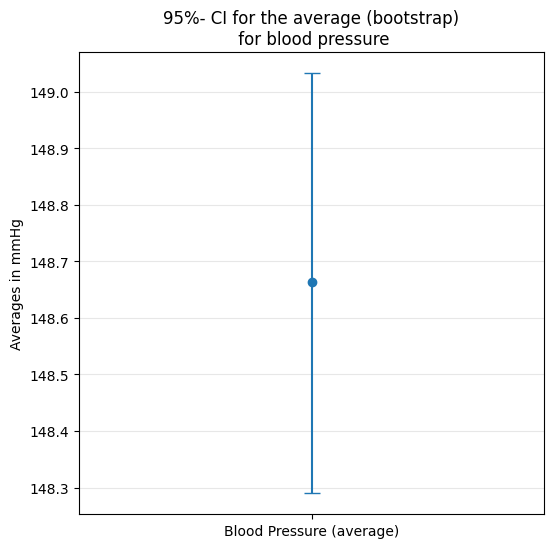

Please note that the bootstrap method gives us a bigger confidence intervall and is less precise than the normal approximation method.
This is due to the size of the simulated sample being quite large (5.000). 


In [6]:
n_lo, n_hi, n_mean_x, _, _ = stats.ci_mean_normal(stats.x)
print(f"Using the normal approximation method:\nthe 95% confidence intervall for the average of the blood pressure is {n_lo:.3f} -{n_hi:.3f} mmHg. ")
stats.ci_mean_normal_graph(n_lo, n_hi, n_mean_x)

b_lo, b_hi, b_mean_x = stats.ci_mean_bootstrap(stats.x)
print(f"Using the normal approximation method:\nthe 95% confidence intervall for the average of the blood pressure is {b_lo:.3f} -{b_hi:.3f} mmHg. ")
stats.ci_mean_boot_graph(b_lo, b_hi, b_mean_x)

print("Please note that the bootstrap method gives us a bigger confidence intervall and is less precise than the normal approximation method.\nThis is due to the size of the simulated sample being quite large (5.000). ")


### Hypotesprövning

Vi testade hypotesen **"Rökare har högre medel-blodtryck än icke-rökare"** med hjälp av bootstrop metod. 
Bootstrap-analysen gav följande resultat:

- **p-värde:** 0.6854  
- **95% konfidensintervall för skillnaden i medelvärden:** -1.636 till 2.465  

**Tolkning:**  
Eftersom p-värdet är betydligt högre än 0.05 och konfidensintervallet innehåller 0 finns det **ingen statistiskt signifikant skillnad** i medel-blodtryck mellan rökare och icke-rökare i detta dataunderlag.

**Slutsats:** Resultaten ger **inte stöd** för hypotesen att rökare har högre medel-blodtryck än icke-rökare.



In [7]:
p_boot, cilow, cihigh, true_diff = stats.hypothesis_test_smoker_bp()

print(f"Bootstrap method: p-value = {p_boot:.4f}, true difference in means = {true_diff:.3f}")
print(f"95% CI for the difference in means: {cilow:.3f} to {cihigh:.3f}")


Bootstrap method: p-value = 0.6854, true difference in means = 0.472
95% CI for the difference in means: -1.636 to 2.465


In [9]:
d, n_per_group = stats.cohen_d_smoker_bp()

print(f"Cohen's d effect size: {d:.3f}")
print(f"Sample size per group: {n_per_group}")

power_analysis = power_analysis.TTestIndPower()
power_t = power_analysis.solve_power(effect_size=d, nobs1=n_per_group, alpha=0.05, ratio=1.0, alternative='larger')
print(f"Calculated power of the test: {power_t:.3f}")

n_needed = power_analysis.solve_power(effect_size=d, power=0.8, alpha=0.05, ratio=1.0, alternative='larger')
print(f"Required sample size per group for 80% power: {n_needed:.0f}")

AttributeError: 'HealthStatistics' object has no attribute 'cohen_d_smoker_bp'

In [ ]:
#Gör en simulering för att undersöka hur säkert ditt hypotes­test är (t.ex. hur ofta testet hittar en skillnad när den finns → power).

import statsmodels.stats.power as power_analysis

A = df.loc[df.smoker == "Yes", "systolic_bp"].values
B = df.loc[df.smoker == "No", "systolic_bp"].values

mu_A = np.mean(A)
mu_B = np.mean(B)

sd_pooled = np.sqrt(((len(A) - 1) * np.var(A, ddof=1) + (len(B) - 1) * np.var(B, ddof=1)) / (len(A) + len(B) - 2))

#print(mu_A, mu_B, sd_pooled) # Checking the calculated values

d = (mu_A - mu_B) / sd_pooled
n_per_group = min(len(A), len(B))

print(f"Cohen's d effect size: {d:.3f}")
print(f"Sample size per group: {n_per_group}")

power_analysis = power_analysis.TTestIndPower()
power_t = power_analysis.solve_power(effect_size=d, nobs1=n_per_group, alpha=0.05, ratio=1.0, alternative='larger')
print(f"Calculated power of the test: {power_t:.3f}")

n_needed = power_analysis.solve_power(effect_size=d, power=0.8, alpha=0.05, ratio=1.0, alternative='larger')
print(f"Required sample size per group for 80% power: {n_needed:.0f}")

print( f"""
The observed effect size (Cohen's d = {power_t:.3f}) is extremely small.
With a sample size of {n_per_group} per group, the statistical power is only {power_t*100:.1f}%, indicating a {100 - (power_t * 100):.1f}% chance of failing to detect the effect.
To achieve 80% power for such a small effect, approximately {n_needed:.0f} participants per group would be required. 
Therefore, the current study is underpowered and the detected effect is likely negligible in practical terms.
""")


# Conclusion of the hypothesis test:

Firstly I used the  bootstrap method to calculate the p-value for a H0 Hypothesis that there is a statistical significant difference in blood pressure between smokers and non-smoker in this dataset.
- The hyptothesis has been rejected as per the values calcuated from the test.
- I ran the test using the steps from lecture video "Hypotesprövning".


Secondly, I ran a power simulation to make sure the study has a high enough chance of detecting a real effect if it actually exists.
- We can conclude from the result that the sample size of the study is too small to notice any significant difference.
- I ran the test using the steps from lecture video "Power & Flerfalding testing".
